# ELECTRA-base ABSA Pipeline

Reference: Clark et al. (2020). ELECTRA. ICLR 2020.

Run all cells top to bottom.

## 1. Imports and Device

In [1]:
import xml.etree.ElementTree as ET
import pandas as pd
import numpy as np
import torch
import random
import re
import os
import json
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict, Counter
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    AutoModelForSequenceClassification,
    Trainer, TrainingArguments, EarlyStoppingCallback
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report
)
import transformers
transformers.logging.set_verbosity_error()
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch:', torch.__version__)
print('Device:', DEVICE)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print('VRAM:', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2), 'GB')


d:\PBL Project Updated\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
W0322 10:54:23.848000 18600 Lib\site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


PyTorch: 2.10.0+cu126
Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
VRAM: 8.59 GB


## 2. Constants

In [2]:
MODEL_CHECKPOINT   = 'google/electra-base-discriminator'
MODEL_KEY          = 'electra'
ATE_OUTPUT_DIR     = './electra_ate_model'
SENT_OUTPUT_DIR    = './electra_sentiment_model'
ATE_FINAL_DIR      = './electra_ate_model_final'
SENT_FINAL_DIR     = './electra_sentiment_model_final'
print('Model:', MODEL_CHECKPOINT)


Model: google/electra-base-discriminator


## 3. Data Loading

In [3]:
MAMS_CAT_MAP = {
    'food':          'food',
    'staff':         'service',
    'service':       'service',
    'price':         'value',
    'ambience':      'ambiance',
    'place':         'ambiance',
    'menu':          'quality',
    'miscellaneous': 'experience',
}

SENT_LABEL_MAP   = {'positive': 0, 'negative': 1, 'neutral': 2, 'conflict': 3}
SENT_LABEL_NAMES = ['positive', 'negative', 'neutral', 'conflict']
ATE_LABEL_MAP    = {'O': 0, 'B-ASP': 1, 'I-ASP': 2}
ATE_LABEL_NAMES  = ['O', 'B-ASP', 'I-ASP']
SCORE_MAP        = {'positive': 1.0, 'negative': -1.0, 'neutral': 0.0, 'conflict': -0.5}
SCORE_VEC        = np.array([SCORE_MAP[l] for l in SENT_LABEL_NAMES])


def parse_semeval_xml(filepath):
    tree = ET.parse(filepath)
    root = tree.getroot()
    records = []
    for sentence in root.findall('sentence'):
        text_node = sentence.find('text')
        if text_node is None or not text_node.text:
            continue
        text = text_node.text
        aspects = []
        aspect_terms = sentence.find('aspectTerms')
        if aspect_terms is not None:
            for asp in aspect_terms.findall('aspectTerm'):
                term     = asp.get('term', '').strip()
                polarity = asp.get('polarity', '').strip().lower()
                cf       = int(asp.get('from', 0))
                ct       = int(asp.get('to', 0))
                if term and polarity in SENT_LABEL_MAP:
                    aspects.append((term, polarity, cf, ct))
        records.append({'text': text, 'aspects': aspects, 'source': 'semeval'})
    return records


def parse_hotels_xml(filepath):
    tree = ET.parse(filepath)
    root = tree.getroot()
    records = []
    for review in root.findall('Review'):
        for sentence in review.find('sentences').findall('sentence'):
            text_node = sentence.find('text')
            if text_node is None or not text_node.text:
                continue
            text = text_node.text
            aspects = []
            opinions = sentence.find('Opinions')
            if opinions is not None:
                for op in opinions.findall('Opinion'):
                    term     = op.get('target', '').strip()
                    polarity = op.get('polarity', '').strip().lower()
                    cf       = int(op.get('target_from', 0))
                    ct       = int(op.get('target_to', 0))
                    if term and term != 'NULL' and polarity in SENT_LABEL_MAP:
                        aspects.append((term, polarity, cf, ct))
            records.append({'text': text, 'aspects': aspects, 'source': 'hotels'})
    return records


def parse_mams_xml(filepath):
    tree = ET.parse(filepath)
    root = tree.getroot()
    records = []
    for sentence in root.findall('sentence'):
        text_node = sentence.find('text')
        if text_node is None or not text_node.text:
            continue
        text = text_node.text.strip()
        aspects = []
        for ac in sentence.findall('aspectCategories/aspectCategory'):
            cat      = ac.get('category', '').strip().lower()
            polarity = ac.get('polarity', '').strip().lower()
            term     = MAMS_CAT_MAP.get(cat, cat)
            if polarity in SENT_LABEL_MAP:
                aspects.append((term, polarity, -1, -1))
        if aspects:
            records.append({'text': text, 'aspects': aspects, 'source': 'mams'})
    return records


restaurant_data = parse_semeval_xml('Restaurants_Test_Gold.xml')
laptop_data     = parse_semeval_xml('Laptops_Test_Gold.xml')
hotel_data      = parse_hotels_xml('Hotels.xml')
mams_train      = parse_mams_xml('train.xml')
mams_test       = parse_mams_xml('test.xml')

all_data_asc = restaurant_data + laptop_data + hotel_data + mams_train + mams_test
all_data_ate = restaurant_data + laptop_data + hotel_data

print(f'Restaurant: {len(restaurant_data)} | Laptop: {len(laptop_data)} | Hotels: {len(hotel_data)}')
print(f'MAMS train: {len(mams_train)} | MAMS test: {len(mams_test)}')
print(f'Total ATE: {len(all_data_ate)} | Total ASC: {len(all_data_asc)}')


Restaurant: 800 | Laptop: 800 | Hotels: 9793
MAMS train: 3149 | MAMS test: 400
Total ATE: 11393 | Total ASC: 14942


## 4. Yelp Sampling

In [4]:
YELP_REVIEW_PATH       = 'yelp_academic_dataset_review.json'
YELP_SAMPLES_PER_CLASS = 5000
YELP_MAX_TEXT_LEN      = 300

def load_yelp_asc_records(review_path, samples_per_class=5000, max_text_len=300):
    buckets = {'positive': [], 'negative': [], 'neutral': []}
    needed  = {k: samples_per_class for k in buckets}

    def star_to_polarity(stars):
        if stars in (1, 2): return 'negative'
        if stars == 3:      return 'neutral'
        return 'positive'

    print(f'Streaming {review_path} ...')
    with open(review_path, 'r', encoding='utf-8') as f:
        for line in f:
            if all(len(buckets[p]) >= needed[p] for p in buckets):
                break
            try:
                obj = json.loads(line)
            except json.JSONDecodeError:
                continue
            text  = obj.get('text', '').replace('\n', ' ').strip()
            stars = int(obj.get('stars', 0))
            if not text or len(text) > max_text_len or stars == 0:
                continue
            pol = star_to_polarity(stars)
            if len(buckets[pol]) < needed[pol]:
                buckets[pol].append({
                    'combined_text': f'overall [SEP] {text}',
                    'aspect':        'overall',
                    'text':          text,
                    'label':         SENT_LABEL_MAP[pol],
                    'polarity':      pol,
                })
    records = []
    for pol, recs in buckets.items():
        records.extend(recs)
        print(f'  {pol}: {len(recs)} records')
    return records


yelp_records = []
if os.path.exists(YELP_REVIEW_PATH):
    yelp_records = load_yelp_asc_records(YELP_REVIEW_PATH, YELP_SAMPLES_PER_CLASS, YELP_MAX_TEXT_LEN)
    print(f'Total Yelp records: {len(yelp_records)}')
else:
    print(f'WARNING: {YELP_REVIEW_PATH} not found. Training without Yelp data.')


Streaming yelp_academic_dataset_review.json ...
  positive: 5000 records
  negative: 5000 records
  neutral: 5000 records
Total Yelp records: 15000


## 5. Build Sentiment Records

In [5]:
def build_sentiment_records(data):
    rows = []
    for record in data:
        text = record['text']
        for (term, polarity, _, _) in record['aspects']:
            rows.append({
                'combined_text': f'{term} [SEP] {text}',
                'aspect':        term,
                'text':          text,
                'label':         SENT_LABEL_MAP[polarity],
                'polarity':      polarity,
            })
    return rows


base_sent_records = build_sentiment_records(all_data_asc)
df_sentiment      = pd.DataFrame(base_sent_records + yelp_records)
print(f'Total sentiment records: {len(df_sentiment)}')
print(df_sentiment['polarity'].value_counts())


Total sentiment records: 33360
polarity
positive    15427
neutral      9007
negative     8892
conflict       34
Name: count, dtype: int64


## 6. Build ATE Records

In [6]:
def build_bio_labels(text, aspects):
    words         = text.split()
    aspect_chars  = set()
    aspect_starts = set()
    for (term, polarity, cf, ct) in aspects:
        if cf < 0:
            continue
        for c in range(cf, ct):
            aspect_chars.add(c)
        aspect_starts.add(cf)
    word_labels = []
    char_pos    = 0
    for word in words:
        ws  = char_pos
        we  = char_pos + len(word)
        in_asp = any(c in aspect_chars for c in range(ws, we))
        is_beg = ws in aspect_starts
        if in_asp and is_beg:
            word_labels.append('B-ASP')
        elif in_asp:
            word_labels.append('I-ASP')
        else:
            word_labels.append('O')
        char_pos = we + 1
    return words, word_labels


def build_ate_records(data):
    records = []
    for record in data:
        if not record['aspects'] or all(a[2] < 0 for a in record['aspects']):
            words = record['text'].split()
            bio   = ['O'] * len(words)
        else:
            words, bio = build_bio_labels(record['text'], record['aspects'])
        records.append({'words': words, 'bio_labels': bio, 'text': record['text']})
    return records


ate_records = build_ate_records(all_data_ate)
all_bio     = [lbl for r in ate_records for lbl in r['bio_labels']]
print(f'ATE records: {len(ate_records)}')
print('BIO distribution:', Counter(all_bio))


ATE records: 11393
BIO distribution: Counter({'O': 160555, 'B-ASP': 8225, 'I-ASP': 2606})


## 7. Augmentation

In [7]:
SYNONYMS = {
    'good': ['great', 'nice', 'decent', 'solid'],
    'bad': ['poor', 'terrible', 'awful', 'weak'],
    'great': ['excellent', 'wonderful', 'fantastic', 'superb'],
    'fast': ['quick', 'speedy', 'swift', 'rapid'],
    'slow': ['sluggish', 'delayed', 'laggy'],
    'expensive': ['pricey', 'costly', 'overpriced'],
    'cheap': ['affordable', 'budget-friendly', 'inexpensive'],
    'delicious': ['tasty', 'flavorful', 'scrumptious'],
    'friendly': ['pleasant', 'welcoming', 'warm'],
    'awful': ['terrible', 'horrible', 'dreadful'],
    'love': ['enjoy', 'like', 'adore'],
    'hate': ['dislike', 'despise', 'loathe'],
    'fresh': ['new', 'clean', 'crisp'],
    'old': ['outdated', 'aged', 'worn'],
    'beautiful': ['lovely', 'gorgeous', 'attractive'],
}
FILLER_WORDS = ['really', 'very', 'quite', 'honestly', 'actually', 'basically', 'generally']


def synonym_replacement(words, bio_labels, n=1):
    nw, nl = words.copy(), bio_labels.copy()
    cands  = [i for i, l in enumerate(bio_labels) if l == 'O']
    random.shuffle(cands)
    replaced = 0
    for idx in cands:
        w = words[idx].lower().strip('.,!?')
        if w in SYNONYMS:
            nw[idx] = random.choice(SYNONYMS[w])
            replaced += 1
        if replaced >= n:
            break
    return nw, nl


def random_insertion(words, bio_labels):
    if not words: return words, bio_labels
    o_pos = [i for i, l in enumerate(bio_labels) if l == 'O']
    if not o_pos: return words, bio_labels
    ip = random.choice(o_pos)
    fw = random.choice(FILLER_WORDS)
    return words[:ip] + [fw] + words[ip:], bio_labels[:ip] + ['O'] + bio_labels[ip:]


def random_deletion(words, bio_labels, p=0.1):
    if len(words) <= 2: return words, bio_labels
    nw, nl = [], []
    for w, l in zip(words, bio_labels):
        if l == 'O' and random.random() < p:
            continue
        nw.append(w); nl.append(l)
    return (nw, nl) if nw else (words, bio_labels)


AUG_FNS = {'synonym': synonym_replacement, 'insert': random_insertion, 'delete': random_deletion}

augmented_ate = list(ate_records)
for rec in ate_records:
    if any(l != 'O' for l in rec['bio_labels']):
        fn_name = random.choice(list(AUG_FNS.keys()))
        nw, nl  = AUG_FNS[fn_name](rec['words'], rec['bio_labels'])
        augmented_ate.append({'words': nw, 'bio_labels': nl, 'text': ' '.join(nw)})

aug_sent_rows = []
for _, row in pd.DataFrame(base_sent_records).iterrows():
    words   = row['text'].split()
    fn_name = random.choice(list(AUG_FNS.keys()))
    nw, _   = AUG_FNS[fn_name](words, ['O'] * len(words))
    nt      = ' '.join(nw)
    aug_sent_rows.append({
        'combined_text': f"{row['aspect']} [SEP] {nt}",
        'aspect': row['aspect'], 'text': nt,
        'label': row['label'], 'polarity': row['polarity'],
    })

df_sentiment_aug = pd.concat([df_sentiment, pd.DataFrame(aug_sent_rows)], ignore_index=True)
print(f'ATE after augmentation: {len(augmented_ate)}')
print(f'ASC after augmentation: {len(df_sentiment_aug)}')


ATE after augmentation: 17220
ASC after augmentation: 51720


## 8. Cleaning

In [8]:
def add_misspellings(text):
    words = text.split()
    if not words: return text
    idx  = random.randint(0, len(words) - 1)
    word = list(words[idx])
    if len(word) >= 2:
        s = random.randint(0, len(word) - 2)
        word[s], word[s+1] = word[s+1], word[s]
    words[idx] = ''.join(word)
    return ' '.join(words)

def add_random_tokens(text):
    garbage = ['###', '...', '???', '!!!', 'xjfk', '@@@@']
    words   = text.split()
    pos     = random.randint(0, len(words))
    words.insert(pos, random.choice(garbage))
    return ' '.join(words)

def break_punctuation(text):
    if random.random() < 0.5:
        return re.sub(r'[.,!?;:]', '', text)
    return text.replace('.', '...')

BAD_FNS      = [add_misspellings, add_random_tokens, break_punctuation]
GARBAGE_PAT  = re.compile(r'(#{2,}|@{2,}|\?{3,}|!{3,}|[a-z]{4,}[fjkxz]{3,})', re.IGNORECASE)

num_bad  = max(10, int(len(df_sentiment_aug) * 0.1))
bad_rows = []
for idx in random.sample(range(len(df_sentiment_aug)), num_bad):
    row = df_sentiment_aug.iloc[idx].copy()
    fn  = random.choice(BAD_FNS)
    row['combined_text'] = fn(row['combined_text'])
    row['text']          = fn(row['text'])
    row['is_bad']        = True
    bad_rows.append(row)

df_sentiment_aug['is_bad'] = False
df_with_bad = pd.concat([df_sentiment_aug, pd.DataFrame(bad_rows)], ignore_index=True)

def detect_bad_text(text):
    if not isinstance(text, str): return True
    words = text.split()
    if len(words) < 3 or len(words) > 100: return True
    if GARBAGE_PAT.search(text): return True
    alpha = sum(1 for c in text if c.isalpha())
    if len(text) > 0 and alpha / len(text) < 0.5: return True
    return False

def clean_text(text):
    if not isinstance(text, str): return ''
    text = re.sub(r'(#{2,}|@{2,}|xjfk|\?{3,})', '', text)
    text = re.sub(r'\.{2,}', '.', text)
    text = re.sub(r'!{2,}', '!', text)
    return re.sub(r'\s+', ' ', text).strip()

df_with_bad['combined_text'] = df_with_bad['combined_text'].apply(clean_text)
df_with_bad['still_bad']     = df_with_bad['combined_text'].apply(detect_bad_text)
df_clean = df_with_bad[~df_with_bad['still_bad']].copy()
print(f'Clean records for training: {len(df_clean)}')
print(df_clean['polarity'].value_counts())


Clean records for training: 56849
polarity
positive    28413
neutral     14353
negative    14010
conflict       73
Name: count, dtype: int64


## 9. Dataset Classes

In [9]:
class ATEDataset(Dataset):
    def __init__(self, records, tokenizer, max_length=128):
        self.records   = records
        self.tokenizer = tokenizer
        self.max_len   = max_length

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec      = self.records[idx]
        words    = rec['words']
        bio      = rec['bio_labels']
        encoding = self.tokenizer(
            words, is_split_into_words=True,
            max_length=self.max_len, padding='max_length',
            truncation=True, return_tensors='pt'
        )
        labels   = []
        prev_wid = None
        for wid in encoding.word_ids():
            if wid is None:
                labels.append(-100)
            elif wid != prev_wid:
                labels.append(ATE_LABEL_MAP[bio[wid]])
            else:
                labels.append(-100)
            prev_wid = wid
        return {
            'input_ids':      encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels':         torch.tensor(labels, dtype=torch.long),
        }


class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx], max_length=self.max_len,
            padding='max_length', truncation=True, return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long),
        }


print('Dataset classes defined.')


Dataset classes defined.


## 10. Train/Test Splits

In [10]:
ate_train, ate_test = train_test_split(augmented_ate, test_size=0.2, random_state=SEED)
print(f'ATE train: {len(ate_train)}, test: {len(ate_test)}')

sent_texts  = df_clean['combined_text'].tolist()
sent_labels = df_clean['label'].tolist()
X_tr, X_te, y_tr, y_te = train_test_split(
    sent_texts, sent_labels, test_size=0.2, random_state=SEED
)
print(f'ASC train: {len(X_tr)}, test: {len(X_te)}')


ATE train: 13776, test: 3444
ASC train: 45479, test: 11370


## 11. Metric Functions

In [11]:
def compute_ate_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    tl, pl = [], []
    for pr, lr in zip(preds, labels):
        for p, l in zip(pr, lr):
            if l != -100:
                tl.append(l); pl.append(p)
    acc  = accuracy_score(tl, pl)
    prec, rec, f1, _ = precision_recall_fscore_support(tl, pl, average='macro', zero_division=0)
    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}


def compute_sent_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc  = accuracy_score(labels, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(labels, preds, average='macro', zero_division=0)
    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}


print('Metric functions defined.')


Metric functions defined.


## 12. ATE Training

In [12]:
tokenizer_ate = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)

ate_model = AutoModelForTokenClassification.from_pretrained(
    MODEL_CHECKPOINT,
    num_labels=3,
    id2label={0: 'O', 1: 'B-ASP', 2: 'I-ASP'},
    label2id=ATE_LABEL_MAP,
    ignore_mismatched_sizes=True,
).to(DEVICE)

ate_train_ds = ATEDataset(ate_train, tokenizer_ate)
ate_test_ds  = ATEDataset(ate_test,  tokenizer_ate)

ate_args = TrainingArguments(
    output_dir=ATE_OUTPUT_DIR,
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_steps=100,
    weight_decay=0.01,
    evaluation_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    logging_steps=50,
    report_to='none',
    fp16=torch.cuda.is_available(),
    dataloader_num_workers=0,
)

ate_trainer = Trainer(
    model=ate_model, args=ate_args,
    train_dataset=ate_train_ds, eval_dataset=ate_test_ds,
    compute_metrics=compute_ate_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print(f'Starting ELECTRA ATE training on {DEVICE} ...')
ate_result = ate_trainer.train()
print('ATE done.', ate_result.metrics)

ate_model.save_pretrained(ATE_FINAL_DIR)
tokenizer_ate.save_pretrained(ATE_FINAL_DIR)
print(f'ATE saved to {ATE_FINAL_DIR}')


Starting ELECTRA ATE training on cuda ...
{'loss': 0.7017, 'grad_norm': 0.7633997201919556, 'learning_rate': 2.3000000000000003e-05, 'epoch': 0.06}
{'loss': 0.1563, 'grad_norm': 1.1543443202972412, 'learning_rate': 4.8e-05, 'epoch': 0.12}
{'loss': 0.1437, 'grad_norm': 0.7269928455352783, 'learning_rate': 4.945303210463734e-05, 'epoch': 0.17}
{'loss': 0.1254, 'grad_norm': 1.0975158214569092, 'learning_rate': 4.885850178359097e-05, 'epoch': 0.23}
{'loss': 0.1111, 'grad_norm': 1.077087163925171, 'learning_rate': 4.826397146254459e-05, 'epoch': 0.29}
{'loss': 0.1093, 'grad_norm': 1.0180115699768066, 'learning_rate': 4.7669441141498216e-05, 'epoch': 0.35}
{'loss': 0.1135, 'grad_norm': 0.5723605751991272, 'learning_rate': 4.707491082045185e-05, 'epoch': 0.41}
{'loss': 0.1027, 'grad_norm': 0.42547082901000977, 'learning_rate': 4.648038049940547e-05, 'epoch': 0.46}
{'loss': 0.111, 'grad_norm': 1.093116044998169, 'learning_rate': 4.5885850178359095e-05, 'epoch': 0.52}
{'loss': 0.1023, 'grad_nor

## 13. ASC Training

In [13]:
tokenizer_sent = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)

sent_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CHECKPOINT,
    num_labels=4,
    id2label={0: 'positive', 1: 'negative', 2: 'neutral', 3: 'conflict'},
    label2id=SENT_LABEL_MAP,
    ignore_mismatched_sizes=True,
).to(DEVICE)

sent_train_ds = SentimentDataset(X_tr, y_tr, tokenizer_sent)
sent_test_ds  = SentimentDataset(X_te, y_te, tokenizer_sent)

sent_args = TrainingArguments(
    output_dir=SENT_OUTPUT_DIR,
    num_train_epochs=6,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_steps=100,
    weight_decay=0.01,
    evaluation_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    logging_steps=50,
    report_to='none',
    fp16=torch.cuda.is_available(),
    dataloader_num_workers=0,
)

sent_trainer = Trainer(
    model=sent_model, args=sent_args,
    train_dataset=sent_train_ds, eval_dataset=sent_test_ds,
    compute_metrics=compute_sent_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print(f'Starting ELECTRA ASC training on {DEVICE} ...')
sent_result = sent_trainer.train()
print('ASC done.', sent_result.metrics)

sent_model.save_pretrained(SENT_FINAL_DIR)
tokenizer_sent.save_pretrained(SENT_FINAL_DIR)
print(f'ASC saved to {SENT_FINAL_DIR}')


Starting ELECTRA ASC training on cuda ...
{'loss': 1.2488, 'grad_norm': 2.0196340084075928, 'learning_rate': 2.5e-05, 'epoch': 0.02}
{'loss': 0.8968, 'grad_norm': 2.695662260055542, 'learning_rate': 4.85e-05, 'epoch': 0.04}
{'loss': 0.7944, 'grad_norm': 6.91811990737915, 'learning_rate': 4.986142233753981e-05, 'epoch': 0.05}
{'loss': 0.7131, 'grad_norm': 6.811447620391846, 'learning_rate': 4.971399929236938e-05, 'epoch': 0.07}
{'loss': 0.7187, 'grad_norm': 5.226377964019775, 'learning_rate': 4.9566576247198964e-05, 'epoch': 0.09}
{'loss': 0.6835, 'grad_norm': 6.22462272644043, 'learning_rate': 4.9419153202028546e-05, 'epoch': 0.11}
{'loss': 0.5853, 'grad_norm': 6.273377895355225, 'learning_rate': 4.927173015685812e-05, 'epoch': 0.12}
{'loss': 0.6102, 'grad_norm': 6.102194786071777, 'learning_rate': 4.9124307111687703e-05, 'epoch': 0.14}
{'loss': 0.5828, 'grad_norm': 3.2411067485809326, 'learning_rate': 4.897688406651728e-05, 'epoch': 0.16}
{'loss': 0.5748, 'grad_norm': 5.74933433532714

## 14. Evaluation

In [14]:
ate_model.eval()
all_true_ate, all_pred_ate = [], []
with torch.no_grad():
    for i in range(len(ate_test_ds)):
        item = ate_test_ds[i]
        out  = ate_model(
            input_ids=item['input_ids'].unsqueeze(0).to(DEVICE),
            attention_mask=item['attention_mask'].unsqueeze(0).to(DEVICE),
        )
        preds  = torch.argmax(out.logits.squeeze(0), dim=-1).cpu().numpy()
        labels = item['labels'].cpu().numpy()
        for p, l in zip(preds, labels):
            if l != -100:
                all_true_ate.append(l); all_pred_ate.append(p)

print('=== ATE Evaluation ===')
print('Accuracy:', round(accuracy_score(all_true_ate, all_pred_ate), 4))
print(classification_report(all_true_ate, all_pred_ate, target_names=ATE_LABEL_NAMES, zero_division=0))

sent_model.eval()
all_true_sent, all_pred_sent = [], []
with torch.no_grad():
    for i in range(len(sent_test_ds)):
        item  = sent_test_ds[i]
        out   = sent_model(
            input_ids=item['input_ids'].unsqueeze(0).to(DEVICE),
            attention_mask=item['attention_mask'].unsqueeze(0).to(DEVICE),
        )
        probs = torch.softmax(out.logits, dim=1).squeeze().cpu().numpy()
        pred  = int(np.argmax(probs))
        all_true_sent.append(int(item['labels']))
        all_pred_sent.append(pred)

print('\n=== ASC Evaluation ===')
print('Accuracy:', round(accuracy_score(all_true_sent, all_pred_sent), 4))
print(classification_report(all_true_sent, all_pred_sent, target_names=SENT_LABEL_NAMES, zero_division=0))


=== ATE Evaluation ===
Accuracy: 0.9822
              precision    recall  f1-score   support

           O       0.99      0.99      0.99     48778
       B-ASP       0.86      0.93      0.89      3296
       I-ASP       0.87      0.88      0.87       993

    accuracy                           0.98     53067
   macro avg       0.91      0.93      0.92     53067
weighted avg       0.98      0.98      0.98     53067


=== ASC Evaluation ===
Accuracy: 0.9143
              precision    recall  f1-score   support

    positive       0.94      0.96      0.95      5746
    negative       0.90      0.89      0.89      2774
     neutral       0.87      0.85      0.86      2831
    conflict       0.88      0.74      0.80        19

    accuracy                           0.91     11370
   macro avg       0.90      0.86      0.88     11370
weighted avg       0.91      0.91      0.91     11370



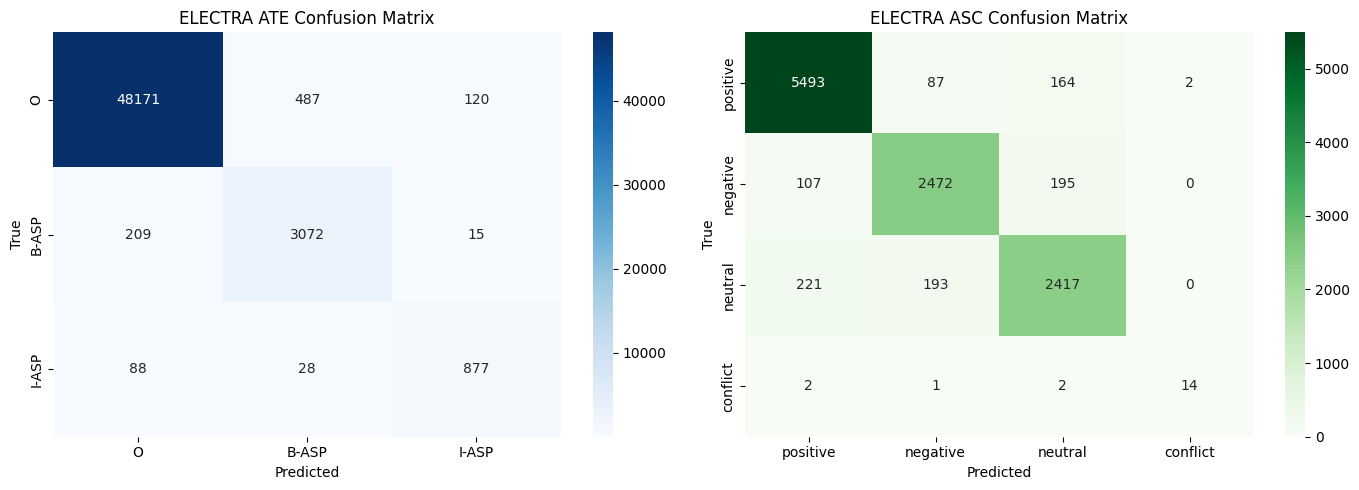

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(confusion_matrix(all_true_ate, all_pred_ate),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=ATE_LABEL_NAMES, yticklabels=ATE_LABEL_NAMES, ax=axes[0])
axes[0].set_title(f'{MODEL_KEY.upper()} ATE Confusion Matrix')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

sns.heatmap(confusion_matrix(all_true_sent, all_pred_sent),
            annot=True, fmt='d', cmap='Greens',
            xticklabels=SENT_LABEL_NAMES, yticklabels=SENT_LABEL_NAMES, ax=axes[1])
axes[1].set_title(f'{MODEL_KEY.upper()} ASC Confusion Matrix')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')

plt.tight_layout()
plt.savefig(f'{MODEL_KEY}_confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()


## 15. Save Config

In [16]:
config = {
    'model_key':             MODEL_KEY,
    'checkpoint':            MODEL_CHECKPOINT,
    'ate_model_path':        ATE_FINAL_DIR,
    'sentiment_model_path':  SENT_FINAL_DIR,
    'ate_label_names':       ATE_LABEL_NAMES,
    'sentiment_label_names': SENT_LABEL_NAMES,
    'sentiment_label_map':   SENT_LABEL_MAP,
    'sentiment_score_map':   SCORE_MAP,
    'ate_accuracy':   round(accuracy_score(all_true_ate,  all_pred_ate),  4),
    'sent_accuracy':  round(accuracy_score(all_true_sent, all_pred_sent), 4),
}
with open(f'pipeline_config_{MODEL_KEY}.json', 'w') as f:
    json.dump(config, f, indent=2)
print(f'Config saved to pipeline_config_{MODEL_KEY}.json')


Config saved to pipeline_config_electra.json
